# PyPSA-USA: Interactive Codebase Tour

This notebook walks through the key components of the PyPSA-USA repository — the configuration system, input data, and geospatial coverage. It is designed to be run inside the dev container, where all packages are already installed.

**What you'll explore:**
1. How the config system works
2. Technology cost assumptions
3. Geospatial coverage of the US grid
4. The workflow DAG
5. *(Placeholder)* A solved network

> 💡 Run cells with `Shift+Enter`. You don't need to run a workflow first — everything here uses static repo data.

---
## Setup

First, set up imports and find the repo root. This works whether you open the notebook from the `notebooks/` directory or from the repo root.

In [ ]:
from pathlib import Path
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
from IPython.display import Image, display
import warnings
warnings.filterwarnings('ignore')

# Locate repo root — works from either guides/ or /workspace
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'guides':
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'workflow').exists(), f"Could not find workflow/ in {REPO_ROOT}"

print(f"✓ Repo root: {REPO_ROOT}")

---
## 1. The Configuration System

PyPSA-USA's behavior is controlled by YAML config files in `workflow/config/`. Snakemake merges all of them at startup — later files override earlier ones.

The most important file is `config.default.yaml`, which sets the scenario: which interconnect to model, how many nodes to cluster to, what time period to simulate, and which technologies to include.

Let's load it and explore its structure.

In [2]:
config_path = REPO_ROOT / 'workflow' / 'config' / 'config.default.yaml'

with open(config_path) as f:
    config = yaml.safe_load(f)

print("Top-level config sections:")
for key in config.keys():
    print(f"  {key}")

Top-level config sections:
  run
  renewable
  scenario
  foresight
  model_topology
  enable
  renewable_weather_years
  snapshots
  renewable_scenarios
  renewable_snapshots
  electricity
  conventional
  lines
  links
  co2
  dac
  costs
  clustering
  focus_weights
  solving
  walltime
  custom_files


### What scenario is currently configured?

The `scenario` block is the first thing to check when you open a new run. It tells you which part of the US is being modeled and at what resolution.

In [3]:
scenario = config['scenario']
snapshots = config['snapshots']
topology = config['model_topology']

print("=== Current scenario ===")
print(f"  Interconnect:          {scenario['interconnect']}")
print(f"  Clusters (nodes):      {scenario['clusters']}")
print(f"  Simulation period:     {snapshots['start']} → {snapshots['end']}")
print(f"  Planning horizons:     {scenario.get('planning_horizons', 'N/A')}")
print(f"  Transmission network:  {topology['transmission_network']}")
print(f"  Spatial resolution:    {topology['topological_boundaries']}")
print(f"  Renewable dataset:     {config['renewable']['dataset']}")

=== Current scenario ===
  Interconnect:          ['western']
  Clusters (nodes):      [33]
  Simulation period:     2019-01-01 → 2020-01-01
  Planning horizons:     [2030, 2040, 2050]
  Transmission network:  reeds
  Spatial resolution:    reeds_zone
  Renewable dataset:     godeeep


**What these settings mean:**

| Setting | Meaning |
|---------|--------|
| `interconnect: [western]` | Model the Western US grid (WECC). Options: `western`, `eastern`, `texas`, `usa` |
| `clusters: [33]` | Aggregate the grid down to 33 nodes. More nodes = more detail but slower to solve |
| `snapshots` | Simulate every hour in 2019. The solver optimizes dispatch across all these hours simultaneously |
| `planning_horizons` | Run the model for 2030, 2040, and 2050 (capacity expansion across time) |
| `transmission_network: reeds` | Use ReEDS transmission data for line capacities |
| `topological_boundaries: reeds_zone` | Aggregate nodes according to ReEDS planning zones |

### Feature flags

The `enable` section controls which optional workflow steps run. See `guides/CODEBASE-NOTES.md` for why this section must be present.

In [4]:
print("Feature flags (enable):")
for flag, value in config.get('enable', {}).items():
    status = '✓ on' if value else '✗ off'
    print(f"  {flag}: {status}")

Feature flags (enable):
  build_cutout: ✗ off


### Conventional generator types

The `electricity` section controls which power plant types are included in the network.

In [5]:
elec = config['electricity']
print("Conventional carriers:", elec.get('conventional_carriers', []))
print("Renewable carriers:   ", elec.get('renewable_carriers', []))
print("Extendable carriers:  ", elec.get('extendable_carriers', {}))

Conventional carriers: ['nuclear', 'oil', 'OCGT', 'CCGT', 'coal', 'geothermal', 'biomass', 'waste']
Renewable carriers:    ['onwind', 'offwind_floating', 'solar', 'hydro']
Extendable carriers:   {'Generator': ['solar', 'onwind', 'offwind_floating', 'OCGT', 'CCGT', 'CCGT-95CCS', 'coal', 'nuclear', 'hydrogen_ct'], 'StorageUnit': ['4hr_battery_storage', '8hr_battery_storage'], 'Store': [], 'Link': []}


---
## 2. Technology Cost Data

PyPSA-USA draws cost assumptions from two main sources:
- **NREL ATB** (Annual Technology Baseline) — capital and operating costs for generators
- **EIA** — fuel costs and CO2 emission factors

These are stored as CSV files in `workflow/repo_data/costs/`. The `build_cost_data` rule processes them into the format PyPSA expects.

In [6]:
costs_dir = REPO_ROOT / 'workflow' / 'repo_data' / 'costs'
print("Files in repo_data/costs/:")
for f in sorted(costs_dir.glob('*.csv')):
    print(f"  {f.name}")

Files in repo_data/costs/:
  additional_costs.csv
  efs_icev_costs.csv
  egs_costs.csv
  eia_tech_costs.csv


In [7]:
# Load the core cost assumptions used across all scenarios
costs = pd.read_csv(costs_dir / 'additional_costs.csv')
print(f"{len(costs)} entries, columns: {list(costs.columns)}")
costs.head(10)

26 entries, columns: ['technology', 'parameter', 'value', 'unit', 'source', 'further_description']


,technology,parameter,value,unit,source,further_description
0,gas,co2_emissions,0.18058,tCO2/MWh_th,EIA,https://www.eia.gov/environment/emissions/co2_...
1,coal,co2_emissions,0.34530,tCO2/MWh_th,EIA,https://www.eia.gov/environment/emissions/co2_...
2,oil,co2_emissions,0.34851,tCO2/MWh_th,EIA,https://www.eia.gov/environment/emissions/co2_...
3,gas,fuel_costs,10.36500,USD/MWh_th,NREL,https://atb.nrel.gov/
4,coal,fuel_costs,4.58800,USD/MWh_th,NREL,https://atb.nrel.gov/
5,oil,fuel_costs,11.75800,USD/MWh_th,NREL,https://atb.nrel.gov/
6,direct firing gas,FOM,1.18180,%/year,"Danish Energy Agency,technology_data_for_indus...",312.a Direct firing Natural Gas: Fixed O&M
7,direct firing gas,VOM,0.27940,EUR/MWh,"Danish Energy Agency,technology_data_for_indus...",312.a Direct firing Natural Gas: Variable O&M
8,direct firing gas,efficiency,0.75000,per unit,"Danish Energy Agency,technology_data_for_indus...",https://www.nrel.gov/docs/fy22osti/81721.pdf
9,direct firing gas,investment,15.10500,EUR/kW,"Danish Energy Agency,technology_data_for_indus...",312.a Direct firing Natural Gas: Nominal inve...


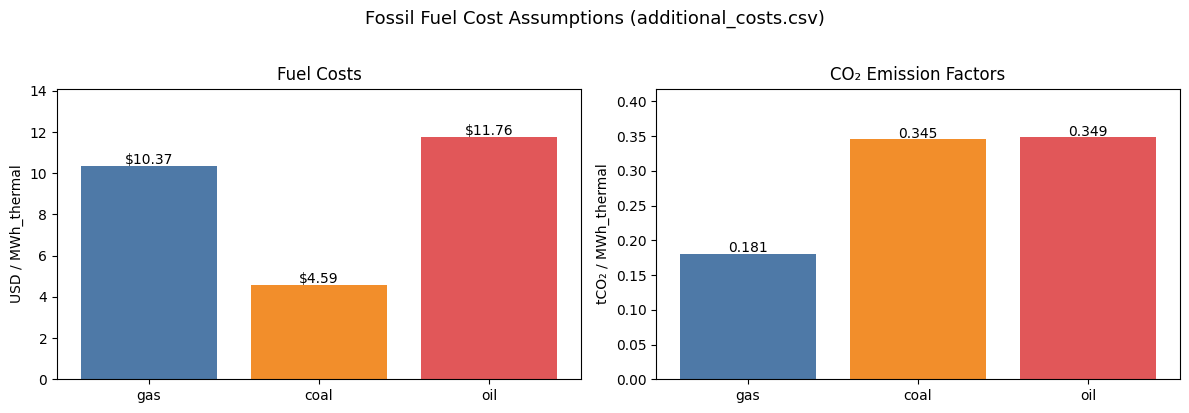

In [8]:
# Fuel costs and CO2 emission factors for fossil fuels
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {'gas': '#4e79a7', 'coal': '#f28e2b', 'oil': '#e15759'}

# Fuel costs
fuel = costs[costs['parameter'] == 'fuel_costs'].copy()
bars = axes[0].bar(
    fuel['technology'],
    fuel['value'],
    color=[colors.get(t, '#bab0ac') for t in fuel['technology']]
)
for bar, val in zip(bars, fuel['value']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'${val:.2f}', ha='center', fontsize=10)
axes[0].set_title('Fuel Costs', fontsize=12)
axes[0].set_ylabel('USD / MWh_thermal')
axes[0].set_ylim(0, max(fuel['value']) * 1.2)

# CO2 emissions
co2 = costs[costs['parameter'] == 'co2_emissions'].copy()
bars2 = axes[1].bar(
    co2['technology'],
    co2['value'],
    color=[colors.get(t, '#bab0ac') for t in co2['technology']]
)
for bar, val in zip(bars2, co2['value']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center', fontsize=10)
axes[1].set_title('CO₂ Emission Factors', fontsize=12)
axes[1].set_ylabel('tCO₂ / MWh_thermal')
axes[1].set_ylim(0, max(co2['value']) * 1.2)

plt.suptitle('Fossil Fuel Cost Assumptions (additional_costs.csv)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Geospatial Coverage

The model represents the US power grid as a network of **nodes** (buses) connected by **transmission lines**. The spatial resolution is controlled by the `clusters` config setting — higher cluster counts = more nodes = finer geographic detail.

Before clustering, the model works with real US geographic boundaries. The repo includes several shapefiles:

In [9]:
geo_dir = REPO_ROOT / 'workflow' / 'repo_data' / 'geospatial'
print("Geospatial datasets:")
for d in sorted(geo_dir.iterdir()):
    if d.is_dir():
        shapefiles = list(d.glob('*.shp'))
        if shapefiles:
            print(f"  {d.name}/")
            for s in shapefiles:
                print(f"    {s.name}")

Geospatial datasets:
  BA_shapes_new/
    Modified_BE_BA_Shapes.shp
    remap_ba_area.shp
  BOEM_CA_OSW_GIS/
    CA_OSW_BOEM_CallAreas.shp
  NERC_Regions/
    NERC_Regions_Subregions.shp
  Reeds_Shapes/
    rb_and_ba_areas.shp


In [10]:
# NERC reliability regions — the high-level planning regions of the US grid
nerc_path = geo_dir / 'NERC_Regions' / 'NERC_Regions_Subregions.shp'
nerc = gpd.read_file(nerc_path)
print(f"NERC regions: {len(nerc)} features")
print(f"Columns: {list(nerc.columns)}")
nerc.head()

NERC regions: 16 features
Columns: ['OBJECTID', 'ID', 'NAME', 'ADDRESS', 'CITY', 'STATE', 'ZIP', 'COUNTRY', 'SOURCE', 'SOURCEDATE', 'VAL_METHOD', 'VAL_DATE', 'WEBSITE', 'SUBNAME', 'SHAPE_Leng', 'SHAPE_Area', 'geometry']


,OBJECTID,ID,NAME,ADDRESS,CITY,STATE,ZIP,COUNTRY,SOURCE,SOURCEDATE,VAL_METHOD,VAL_DATE,WEBSITE,SUBNAME,SHAPE_Leng,SHAPE_Area,geometry
0,1,1,WESTERN ELECTRICITY COORDINATING COUNCIL (WECC),155 NORTH 400 WEST SUITE 200,SALT LAKE CITY,UT,84103,USA,"EIA 861, https://www.nerc.com/, https://www.ne...",2010-10-01,OTHER,2022-06-03,https://www.wecc.biz/Pages/home.aspx,AZ-NM-SNV,5.664517e+06,8.498212e+11,"POLYGON ((-12299776.254 4439628.108, -12298306..."
1,2,2,WESTERN ELECTRICITY COORDINATING COUNCIL (WECC),156 NORTH 400 WEST SUITE 200,SALT LAKE CITY,UT,84103,USA,"EIA 861, https://www.nerc.com/, https://www.ne...",2010-10-01,OTHER,2022-06-03,https://www.wecc.biz/Pages/home.aspx,CA-MX US,6.630059e+06,5.793996e+11,"MULTIPOLYGON (((-13038708.354 3845228.346, -13..."
2,3,3,TEXAS RELIABILITY ENTITY (TRE),800 AIRPORT ROAD,TAYLOR,TX,76574,USA,"EIA 861, https://www.nerc.com/, https://www.ne...",2010-10-01,OTHER,2022-06-03,http://www.ercot.com/,ERCOT,1.152261e+07,7.156840e+11,"MULTIPOLYGON (((-10822667.912 2996855.452, -10..."
3,4,4,FLORIDA RELIABILITY COORDINATING COUNCIL (FRCC),"3000 BAYPORT DRIVE, SUITE 600",TAMPA,FL,33607,USA,"EIA 861, https://www.nerc.com/, https://www.ne...",2010-10-01,OTHER,2022-06-03,https://www.frcc.com/default.aspx,FRCC,1.389346e+07,1.646775e+11,"MULTIPOLYGON (((-9124110.593 2817072.91, -9124..."
4,5,5,NORTHEAST POWER COORDINATING COUNCIL (NPCC),"1040 AVENUE OF THE AMERICAS, 10TH FLOOR",NEW YORK,NY,10018,USA,"EIA 861, https://www.nerc.com/, https://www.ne...",2010-10-01,OTHER,2022-06-03,https://www.npcc.org/default.aspx,NEW ENGLAND,9.169736e+06,3.334812e+11,"MULTIPOLYGON (((-8195678.21 5009974.581, -8195..."


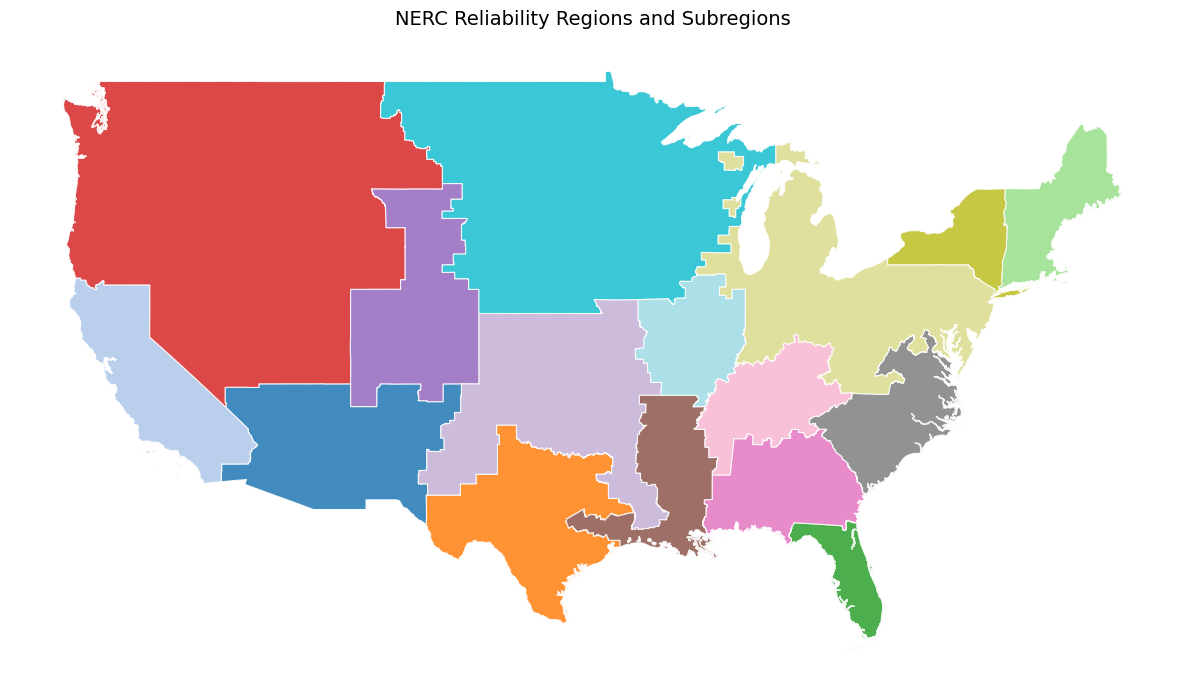

In [11]:
fig, ax = plt.subplots(figsize=(13, 7))
nerc.plot(
    ax=ax,
    column=nerc.columns[0],
    cmap='tab20',
    edgecolor='white',
    linewidth=0.8,
    legend=False,
    alpha=0.85
)
ax.set_title('NERC Reliability Regions and Subregions', fontsize=14, pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

In [12]:
# Balancing authority areas — the operational control regions
# These map roughly to utilities and grid operators (CAISO, MISO, PJM, etc.)
ba_path = geo_dir / 'BA_shapes_new' / 'Modified_BE_BA_Shapes.shp'
ba = gpd.read_file(ba_path)
print(f"Balancing authorities: {len(ba)} areas")
print(f"Columns: {list(ba.columns)}")

Balancing authorities: 115 areas
Columns: ['BA', 'layer', 'path', 'geometry']


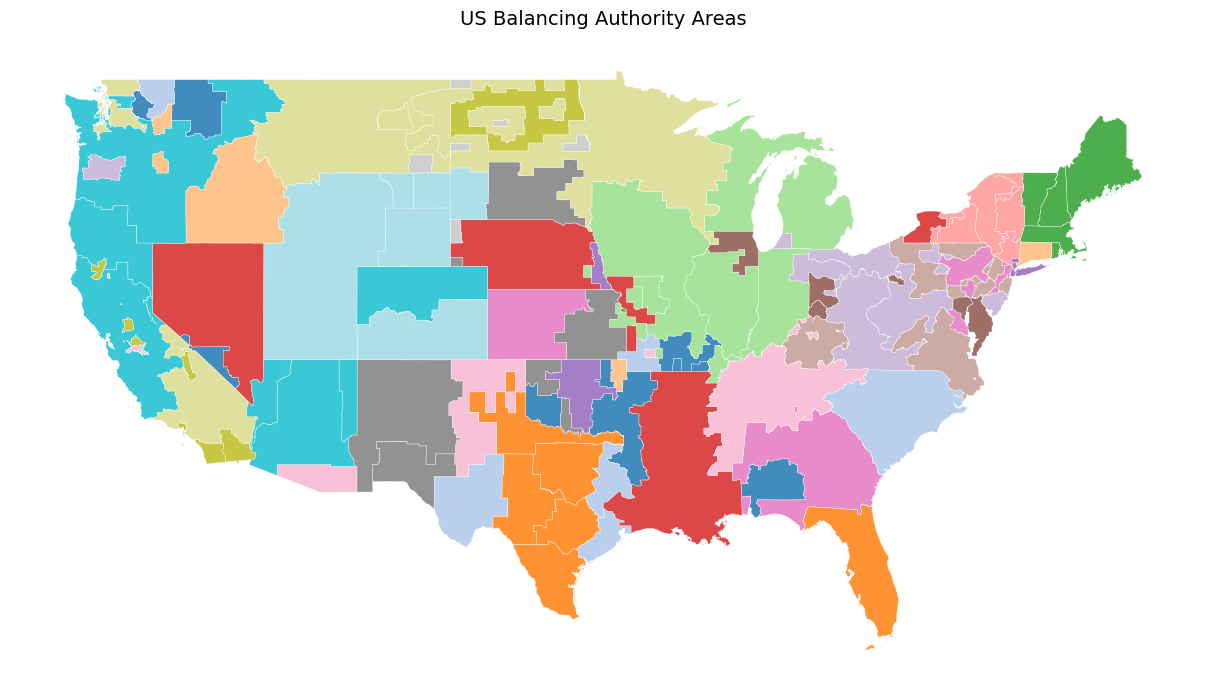


Note: 'clusters' in the config aggregates the BAs above into N nodes.
With clusters=33, the Western interconnect becomes 33 nodes.


In [13]:
fig, ax = plt.subplots(figsize=(13, 7))
ba.plot(
    ax=ax,
    edgecolor='white',
    linewidth=0.3,
    cmap='tab20',
    alpha=0.85
)
ax.set_title('US Balancing Authority Areas', fontsize=14, pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

print()
print("Note: 'clusters' in the config aggregates the BAs above into N nodes.")
print(f"With clusters=33, the Western interconnect becomes 33 nodes.")

---
## 4. The Workflow DAG

Snakemake represents the full workflow as a directed acyclic graph (DAG). Each node is a rule execution; arrows show data dependencies. The repo includes a pre-rendered DAG image.

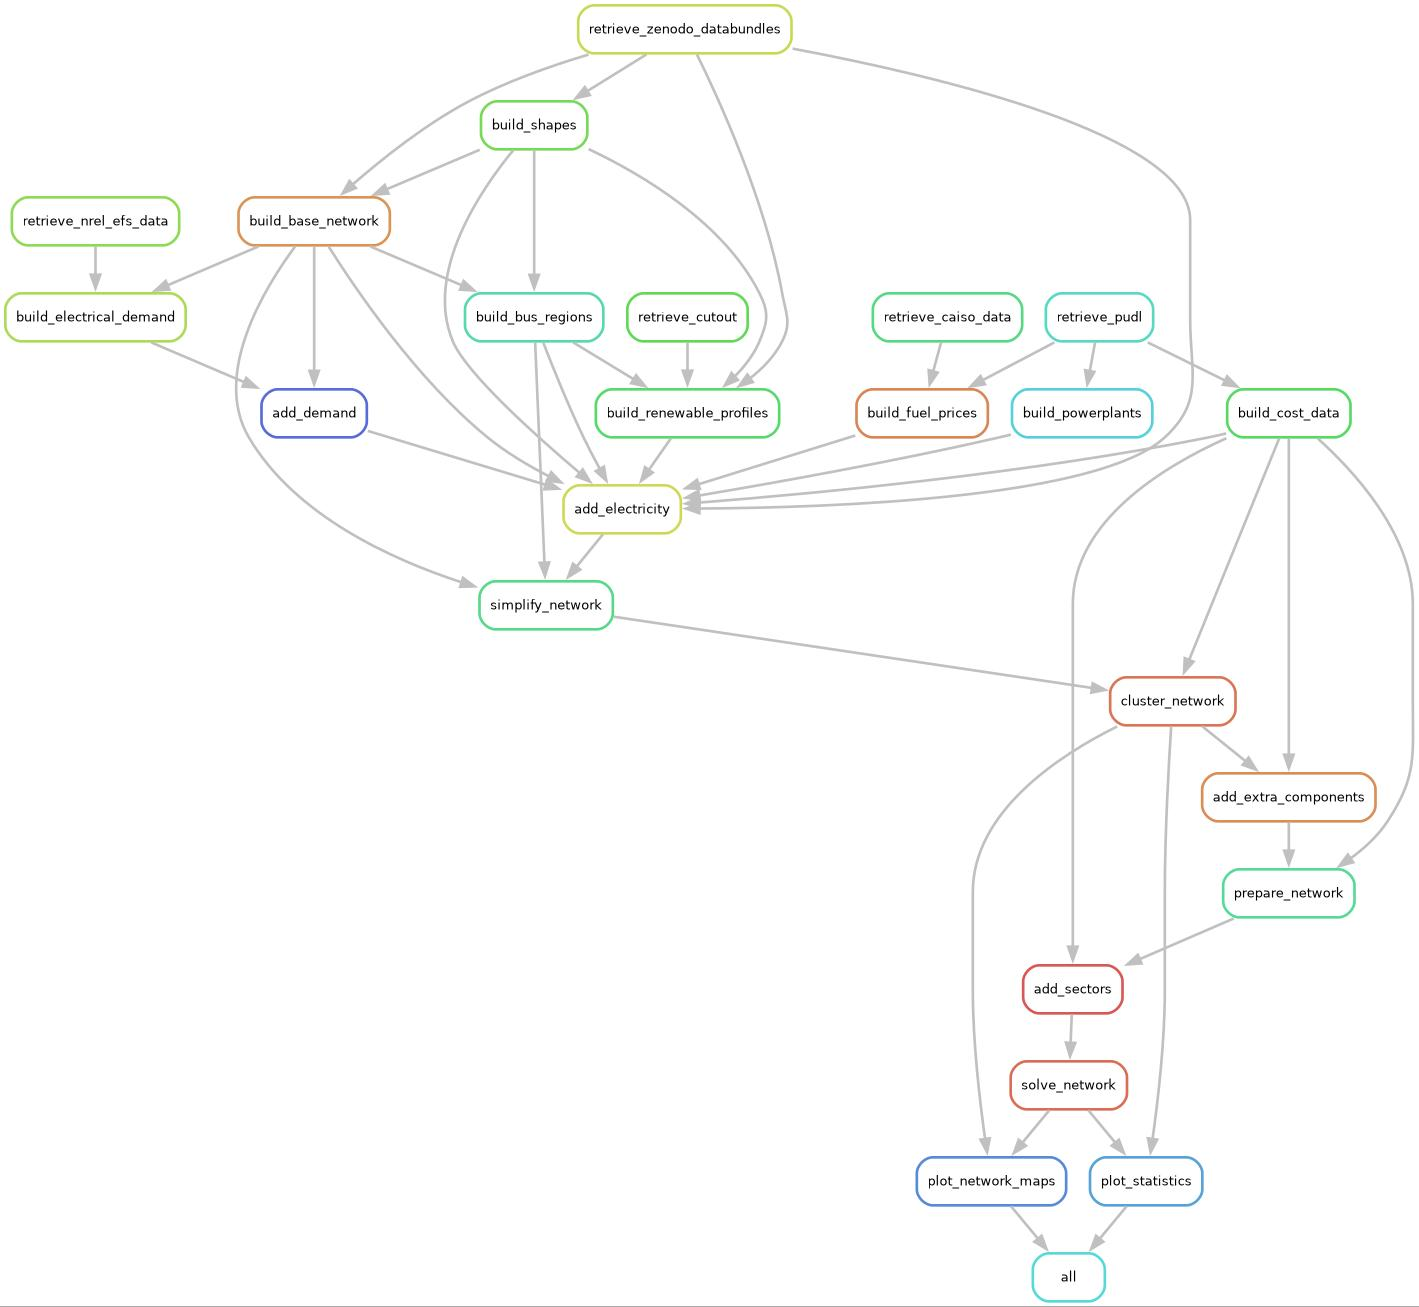

In [14]:
dag_path = REPO_ROOT / 'workflow' / 'repo_data' / 'dag.jpg'
if dag_path.exists():
    display(Image(str(dag_path), width=900))
else:
    print("DAG image not found. Generate it with:")
    print("  cd workflow && snakemake --dag | dot -Tsvg > dag.svg")

You can also generate a live DAG for your current config from the terminal:

```bash
cd workflow
snakemake --dag | dot -Tsvg > dag.svg
```

The live DAG shows exactly which rules will run for *your* scenario — including only the rules that apply to your configured interconnect, foresight mode, and sector settings.

---
## 5. Solved Network *(placeholder)*

After running the full workflow, the `solve_network` rule produces a `.nc` file containing the optimized network — every bus, generator, transmission line, and their solved capacities and hourly dispatch.

PyPSA provides rich tools for exploring solved networks. The cells below are placeholders — update `NETWORK_PATH` to point to a solved `.nc` file.

In [15]:
# ⚠️ PLACEHOLDER — update this path to a solved network file
NETWORK_PATH = None  # e.g. Path('results/Default/networks/elec_s_33_ec_lv1.0_REM-3h_2030.nc')

if NETWORK_PATH and Path(NETWORK_PATH).exists():
    import pypsa
    n = pypsa.Network(NETWORK_PATH)
    print(n)
else:
    print("No solved network loaded. Run the workflow first, then update NETWORK_PATH above.")
    print()
    print("Once loaded, a PyPSA network contains:")
    print("  n.buses        — nodes (geographic locations)")
    print("  n.generators   — power plants with capacity and costs")
    print("  n.lines        — AC transmission lines")
    print("  n.links        — DC lines and other directed connections")
    print("  n.loads        — demand at each bus")
    print("  n.storage_units — batteries and other storage")

No solved network loaded. Run the workflow first, then update NETWORK_PATH above.

Once loaded, a PyPSA network contains:
  n.buses        — nodes (geographic locations)
  n.generators   — power plants with capacity and costs
  n.lines        — AC transmission lines
  n.links        — DC lines and other directed connections
  n.loads        — demand at each bus
  n.storage_units — batteries and other storage


In [ ]:
# ⚠️ PLACEHOLDER — network map
if NETWORK_PATH and Path(NETWORK_PATH).exists():
    import pypsa
    n = pypsa.Network(NETWORK_PATH)
    fig, ax = plt.subplots(figsize=(12, 7))
    n.plot(ax=ax, title='Solved Network — Optimal Capacities')
    plt.show()
else:
    print("⚠️  Placeholder: network map will appear here once NETWORK_PATH is set.")

In [ ]:
# ⚠️ PLACEHOLDER — generation mix
if NETWORK_PATH and Path(NETWORK_PATH).exists():
    import pypsa
    n = pypsa.Network(NETWORK_PATH)
    gen = n.generators.groupby('carrier')['p_nom_opt'].sum() / 1e3  # GW
    gen = gen[gen > 0.1].sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 5))
    gen.plot.bar(ax=ax)
    ax.set_ylabel('Optimal capacity (GW)')
    ax.set_title('Optimal Generation Mix')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Placeholder: generation mix chart will appear here once NETWORK_PATH is set.")

---
## 6. Running the workflow

Once you have config files in place (`bash init_pypsa_usa.sh` from the repo root), run the workflow from the `workflow/` directory:

```bash
# See what would run without executing anything
cd workflow
snakemake --dry-run

# Run with 4 parallel cores
snakemake --cores 4

# Run a specific rule only
snakemake build_base_network --cores 1
```

Output files land in `workflow/results/` and `workflow/resources/`, organized by run name. The run name is set by `config.run.name` in your config.

### Common gotchas

- **`KeyError: 'enable'`** — `config.default.yaml` is commented out in `Snakefile` line 92. Uncomment it.
- **Config not found** — Run Snakemake from `workflow/`, not the repo root.
- **Missing config files** — Run `bash init_pypsa_usa.sh` from the repo root first.

See `guides/CODEBASE-NOTES.md` for more.

---
## Further reading

| Resource | What it covers |
|----------|----------------|
| [PyPSA docs](https://pypsa.readthedocs.io) | Network components, optimization formulation, plotting API |
| [Snakemake docs](https://snakemake.readthedocs.io) | Rule syntax, wildcards, cluster execution |
| `guides/INTRO.md` | Text + diagram overview of this codebase |
| `docs/source/config-configuration.md` | Full reference for every config key |
| `guides/CODEBASE-NOTES.md` | Non-obvious behaviors and debugging gotchas |